# DRL Assignment I — Group 150 — Bandit Algorithms Demo
**Paper:** Bouneffouf, D. & Rish, I. (2019). *A Survey on Practical Applications of Multi-Armed and Contextual Bandits.* arXiv:1904.10040

The survey sorts every application into **4 settings**: MAB, non-stationary MAB, CMAB and non-stationary CMAB (Tables 1 & 2).
It runs no experiments itself, so this notebook **checks the core algorithms it reviews** on simulated problems:

| Experiment | Survey setting | Algorithms compared | Survey reference |
|---|---|---|---|
| 1 | Stationary MAB | ε-greedy, UCB1, Thompson Sampling | Auer et al. 2002; Agrawal & Goyal 2012 |
| 2 | Contextual MAB | LinUCB vs context-blind UCB1 vs random | Li et al. 2010 |
| 3 | Non-stationary MAB | Thompson Sampling vs Discounted TS | Survey §2.10 / §3.7 (non-stationary settings) |

**Metric:** cumulative regret, $R(T)=\sum_{t=1}^{T}\big(\mu^* - \mu_{a_t}\big)$. Lower is better, and a curve that flattens means the agent has learned.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs('figures', exist_ok=True)
SEED = 150          # group number, for reproducibility
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})

## Experiment 1 — Stationary Bernoulli MAB
5 arms with fixed success probabilities (think of 5 ad variants or 5 drugs in a trial: the survey's healthcare / A/B testing example).
All algorithms are vectorised over `RUNS` independent repetitions so the results average out noise.

- **ε-greedy:** explore at random with probability ε, otherwise pick the best arm so far.
- **UCB1** (Auer 2002): $a_t=\arg\max_i \hat\mu_i+\sqrt{2\ln t/N_i}$, i.e. optimism under uncertainty.
- **Thompson Sampling** (Agrawal & Goyal 2012): sample $\theta_i\sim\text{Beta}(S_i+1,F_i+1)$ and pull $\arg\max_i\theta_i$, i.e. posterior sampling.

In [2]:
MU = np.array([0.10, 0.25, 0.40, 0.55, 0.60])   # true success probabilities; best arm = 4
K, T, RUNS = len(MU), 10000, 200

def run_mab(policy, mu=MU, T=T, runs=RUNS, seed=SEED, **kw):
    rng = np.random.default_rng(seed)
    N = np.zeros((runs, K)); S = np.zeros((runs, K))
    regret = np.zeros((runs, T)); opt = np.zeros((runs, T))
    idx = np.arange(runs)
    for t in range(T):
        if policy == 'egreedy':
            est = np.where(N > 0, S / np.maximum(N, 1), 1.0)       # try every arm once
            a = est.argmax(1)
            explore = rng.random(runs) < kw['eps']
            a[explore] = rng.integers(0, K, explore.sum())
        elif policy == 'ucb1':
            if t < K: a = np.full(runs, t)
            else:     a = (S / N + np.sqrt(2 * np.log(t + 1) / N)).argmax(1)
        elif policy == 'ts':
            a = rng.beta(S + 1, N - S + 1).argmax(1)
        r = rng.random(runs) < mu[a]
        N[idx, a] += 1; S[idx, a] += r
        regret[:, t] = mu.max() - mu[a]
        opt[:, t] = a == mu.argmax()
    return regret.cumsum(1), opt

res1 = {
    'ε-greedy (ε=0.1)': run_mab('egreedy', eps=0.1),
    'UCB1':             run_mab('ucb1'),
    'Thompson Sampling': run_mab('ts'),
}

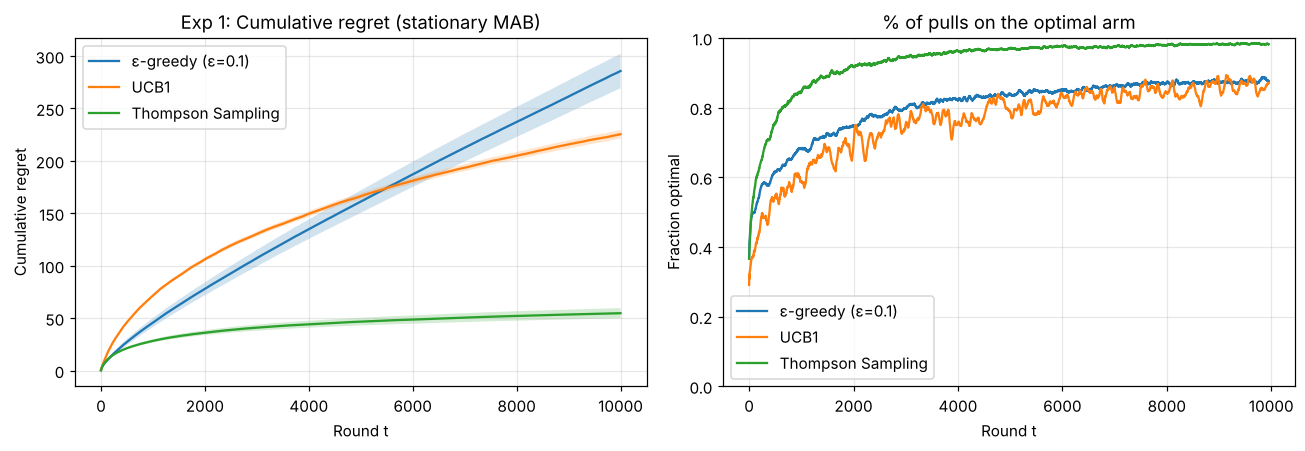

Algorithm                Regret@T  Optimal-arm % (last 1000)
ε-greedy (ε=0.1)            285.8                      87.5%
UCB1                        225.4                      86.3%
Thompson Sampling            54.7                      98.3%


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for name, (cr, opt) in res1.items():
    m, s = cr.mean(0), cr.std(0) / np.sqrt(RUNS)
    ax[0].plot(m, label=name); ax[0].fill_between(range(T), m - 2*s, m + 2*s, alpha=.2)
    ax[1].plot(np.convolve(opt.mean(0), np.ones(50)/50, 'valid'), label=name)
ax[0].set(title='Exp 1: Cumulative regret (stationary MAB)', xlabel='Round t', ylabel='Cumulative regret')
ax[1].set(title='% of pulls on the optimal arm', xlabel='Round t', ylabel='Fraction optimal', ylim=(0, 1))
ax[0].legend(); ax[1].legend()
plt.tight_layout(); plt.savefig('figures/exp1_stationary_mab.png', dpi=150); plt.show()

print(f"{'Algorithm':22s} {'Regret@T':>10s} {'Optimal-arm % (last 1000)':>26s}")
for name, (cr, opt) in res1.items():
    print(f"{name:22s} {cr[:, -1].mean():10.1f} {100*opt[:, -1000:].mean():25.1f}%")

**Interpretation** (exact numbers are in the printed table above):
- **ε-greedy** regret grows *linearly*: it keeps exploring at random 10% of the time forever, even after finding the best arm.
- **UCB1** regret grows *logarithmically*, but with a large constant: the two best arms (0.55 vs 0.60) are close, and UCB1's Hoeffding bound keeps re-checking them. So ε-greedy is actually ahead early on, and **UCB1 overtakes it at around t ≈ 5,500**. This shows the difference between an asymptotic guarantee and early-round performance.
- **Thompson Sampling** has by far the lowest regret throughout (about 4× lower than UCB1 at T), which matches the empirical finding that made TS a standard baseline (Agrawal & Goyal 2012; Chapelle & Li 2011).
- Takeaway: UCB1 and TS are the two canonical families the survey names (stochastic vs Bayesian, §1), and both beat naive ε-greedy in the long run.

## Experiment 2 — Contextual MAB (LinUCB)
The survey's key distinction (§1): in a **CMAB** the agent sees a context vector $x_t$ before acting, and the best arm *depends on the context*
(e.g. Yahoo! news personalisation, Li et al. 2010; Warfarin dosing from patient covariates, Bastani & Bayati 2015).

Simulation: $d=5$ user features, $K=5$ arms, each with a hidden weight vector $\theta_a$; reward $= x_t^\top\theta_a + \text{noise}$.

**LinUCB** (disjoint, Li et al. 2010): per arm, keep $A_a = I+\sum x x^\top$ and $b_a=\sum r x$; then
$\hat\theta_a=A_a^{-1}b_a$ and $a_t=\arg\max_a\, x_t^\top\hat\theta_a+\alpha\sqrt{x_t^\top A_a^{-1}x_t}$.

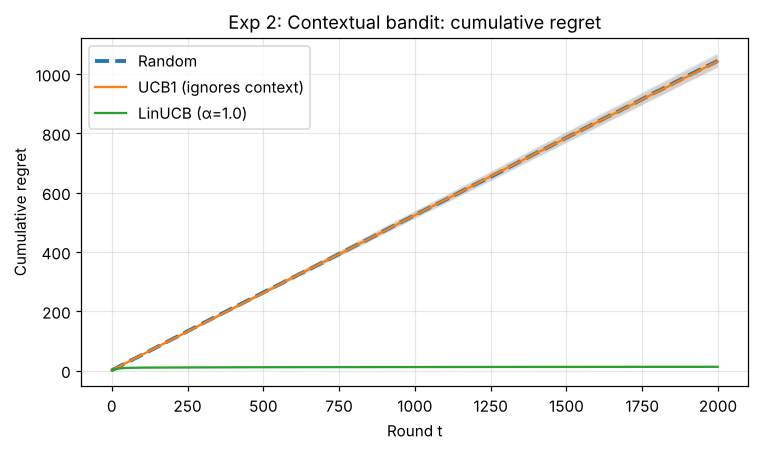

Random                    regret@T =  1044.1
UCB1 (ignores context)    regret@T =  1043.2
LinUCB (α=1.0)            regret@T =    12.5


In [4]:
d, K2, T2, RUNS2, NOISE = 5, 5, 2000, 50, 0.1

def run_contextual(policy, alpha=1.0, seed=SEED):
    rng = np.random.default_rng(seed)
    out = np.zeros((RUNS2, T2))
    for run in range(RUNS2):
        theta = rng.normal(size=(K2, d)); theta /= np.linalg.norm(theta, axis=1, keepdims=True)
        A = np.stack([np.eye(d)] * K2); b = np.zeros((K2, d))
        N = np.zeros(K2); S = np.zeros(K2)
        for t in range(T2):
            x = rng.normal(size=d); x /= np.linalg.norm(x)
            exp_r = theta @ x                                   # expected reward of each arm in this context
            if policy == 'linucb':
                Ainv = np.linalg.inv(A)
                th_hat = np.einsum('kij,kj->ki', Ainv, b)
                ucb = th_hat @ x + alpha * np.sqrt(np.einsum('i,kij,j->k', x, Ainv, x))
                a = ucb.argmax()
            elif policy == 'ucb1':                             # ignores context
                a = t if t < K2 else (S / N + np.sqrt(2 * np.log(t + 1) / N)).argmax()
            else:
                a = rng.integers(K2)
            r = exp_r[a] + NOISE * rng.normal()
            A[a] += np.outer(x, x); b[a] += r * x; N[a] += 1; S[a] += r
            out[run, t] = exp_r.max() - exp_r[a]
    return out.cumsum(1)

res2 = {'Random': run_contextual('random'),
        'UCB1 (ignores context)': run_contextual('ucb1'),
        'LinUCB (α=1.0)': run_contextual('linucb')}

plt.figure(figsize=(7, 4.2))
for name, cr in res2.items():
    m, s = cr.mean(0), cr.std(0) / np.sqrt(RUNS2)
    plt.plot(m, label=name, ls='--' if name == 'Random' else '-', lw=2.5 if name == 'Random' else 1.5)
    plt.fill_between(range(T2), m - 2*s, m + 2*s, alpha=.2)
plt.title('Exp 2: Contextual bandit: cumulative regret'); plt.xlabel('Round t'); plt.ylabel('Cumulative regret'); plt.legend()
plt.tight_layout(); plt.savefig('figures/exp2_contextual_linucb.png', dpi=150); plt.show()
for name, cr in res2.items(): print(f'{name:25s} regret@T = {cr[:, -1].mean():7.1f}')

**Interpretation.** In this simulation every arm has the *same* average reward over all contexts (random θ, zero-mean x), so a context-blind algorithm like UCB1 does **no better than random**: there is no single best arm.
LinUCB learns a per-arm linear model and picks the best arm *for each context*, so its regret flattens.
This is the survey's motivation for CMAB in personalisation, pricing and healthcare (Table 1: CMAB is the most-used column).

## Experiment 3 — Non-stationary MAB
The survey's tables (§2.10, §3.7) show that **non-stationary** settings are rarely studied outside recommender systems, and name this as an open direction.
Here the reward probabilities **change abruptly at t = 1500** (e.g. user tastes shift, or news goes stale: the survey's freshness-aware TS example in §2.4).

- **Standard TS** keeps all past evidence, so after the change it is very slow to switch.
- **Discounted TS** multiplies past counts by γ < 1 every round, so old evidence fades and the agent can adapt.

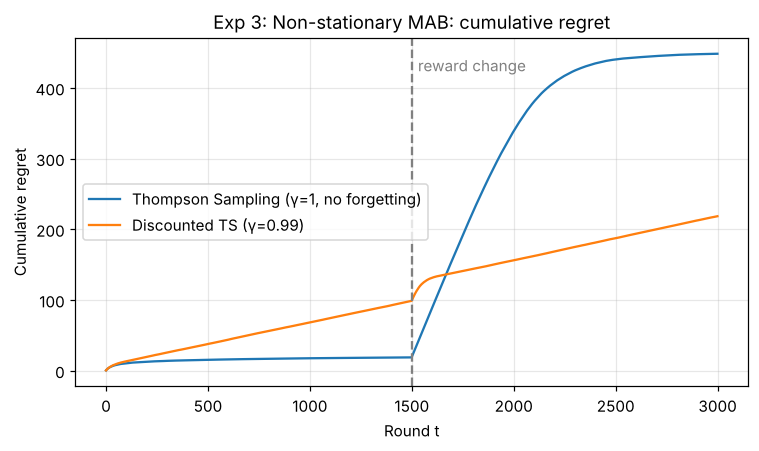

Thompson Sampling (γ=1, no forgetting)   regret before change =   18.7 | total =   448.2
Discounted TS (γ=0.99)                   regret before change =   98.8 | total =   218.4


In [5]:
MU_A = np.array([0.10, 0.25, 0.40, 0.55, 0.80])
MU_B = MU_A[::-1].copy()                    # best arm flips from 4 to 0 at the change point
T3, CHANGE = 3000, 1500

def run_nonstat(gamma, runs=RUNS, seed=SEED):
    rng = np.random.default_rng(seed)
    S = np.zeros((runs, K)); F = np.zeros((runs, K)); idx = np.arange(runs)
    reg = np.zeros((runs, T3))
    for t in range(T3):
        mu = MU_A if t < CHANGE else MU_B
        a = rng.beta(S + 1, F + 1).argmax(1)
        r = rng.random(runs) < mu[a]
        S *= gamma; F *= gamma
        S[idx, a] += r; F[idx, a] += 1 - r
        reg[:, t] = mu.max() - mu[a]
    return reg.cumsum(1)

res3 = {'Thompson Sampling (γ=1, no forgetting)': run_nonstat(1.0),
        'Discounted TS (γ=0.99)': run_nonstat(0.99)}

plt.figure(figsize=(7, 4.2))
for name, cr in res3.items():
    plt.plot(cr.mean(0), label=name)
plt.axvline(CHANGE, ls='--', c='grey'); plt.text(CHANGE + 30, plt.ylim()[1]*0.9, 'reward change', color='grey')
plt.title('Exp 3: Non-stationary MAB: cumulative regret'); plt.xlabel('Round t'); plt.ylabel('Cumulative regret'); plt.legend()
plt.tight_layout(); plt.savefig('figures/exp3_nonstationary.png', dpi=150); plt.show()
for name, cr in res3.items():
    print(f'{name:40s} regret before change = {cr[:, CHANGE-1].mean():6.1f} | total = {cr[:, -1].mean():7.1f}')

**Interpretation.** This shows a real **trade-off**. *Before* the change, standard TS has much lower regret, because discounting throws away useful evidence and keeps the discounted agent exploring in a stable world.
*After* the change, standard TS stays stuck on the old best arm for a long time, while discounted TS recovers within roughly 1/(1−γ) ≈ 100 rounds.
Over the full run discounted TS ends with about half the regret. This supports the survey's point that **non-stationary bandits are needed** where the environment drifts (§2.10, §3.7 future directions).

## Summary for the slides
| Setting (survey Table 1/2 column) | Result |
|---|---|
| Stationary MAB | TS best; UCB1 logarithmic but overtakes ε-greedy only after ~5.5k rounds |
| CMAB | LinUCB about 80× lower regret than context-blind UCB1, so context is essential |
| Non-stationary MAB | Discounting costs regret when the world is stable but halves total regret under drift |

## References
1. Bouneffouf, D., & Rish, I. (2019). A Survey on Practical Applications of Multi-Armed and Contextual Bandits. arXiv:1904.10040.
2. Auer, P., Cesa-Bianchi, N., & Fischer, P. (2002). Finite-time analysis of the multiarmed bandit problem. *Machine Learning*, 47(2–3), 235–256.
3. Agrawal, S., & Goyal, N. (2012). Analysis of Thompson Sampling for the multi-armed bandit problem. *COLT 2012*.
6. Chapelle, O., & Li, L. (2011). An empirical evaluation of Thompson Sampling. *NeurIPS 2011*.
4. Li, L., Chu, W., Langford, J., & Schapire, R. E. (2010). A contextual-bandit approach to personalized news article recommendation. *WWW 2010*.
5. Raj, V., & Kalyani, S. (2017). Taming non-stationary bandits: A Bayesian approach. arXiv:1707.09727 (discounted Thompson Sampling).